In [24]:
 # Setup plotting, seaborn is just used to make figures look a bit nicer not required
%matplotlib inline
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_context('talk')
except ModuleNotFoundError:
    print('Dont worry')

In [25]:
import numpy as np
from ase.io import read
from ase.db import connect
from hiphive import ClusterSpace, StructureContainer
from hiphive.utilities import get_displacements
from trainstation import Optimizer
from hiphive import ClusterSpace, StructureContainer, ForceConstantPotential
from phonopy import Phonopy
from phonopy.structure.atoms import PhonopyAtoms
from ase import Atoms


In [4]:
cutoffs = [12, 5.5]
cutoffs_str = str(cutoffs)[1:-1].replace(', ', '_')
sc_fname = 'sc_cutoffs-{}.sc'.format(cutoffs_str)

In [11]:
atoms_ideal = read('./POSCAR_ideal')
cs = ClusterSpace(atoms_ideal, cutoffs)
sc = StructureContainer(cs)
db = connect('./CsSnI.db')

for row in db.select():

    # get displacements and forces
    atoms = row.toatoms()
    forces = atoms.get_forces()
    displacements = get_displacements(atoms, atoms_ideal)

    # sanity check
    max_disp = np.max(np.linalg.norm(displacements, axis=1))
    #assert max_disp < 0.5

    # add atoms to StructureContainer
    atoms.positions = atoms_ideal.get_positions()
    atoms.new_array('forces', forces)
    atoms.new_array('displacements', displacements)
    sc.add_structure(atoms)

# write to file
sc.write(sc_fname)



Primitive cell:
    Formula: Cs2I6Sn
    Cell:
        [  0.00000   5.83899   5.83899]
        [  5.83899   0.00000   5.83899]
        [  5.83899   5.83899   0.00000]
    Basis:
        Cs  [  0.25000   0.25000   0.25000]
        Cs  [  0.75000   0.75000   0.75000]
        Sn  [  0.00000   0.00000   0.00000]
        ...

Crystal symmetry:
    Spacegroup:          Fm-3m (225)
    Unique site:         3
    Symmetry operations: 48
    symprec:             1.00e-05

Cutoffs:
    Maximum cutoff: 12.0
    Found 9 center atoms with 339 images totaling 348 atoms

Clusters:
    Clusters: {2: 1347, 3: 452}
    Total number of clusters: 1799

Orbits:
    Orbits: {2: 39, 3: 17}
    Total number of orbits: 56

Eigentensors:
    Eigentensors: {2: 166, 3: 122}
    Total number of parameters: 288
    Discarded orbits:
        (2, 2, 2)

Constraints:
    Acoustic: True
    Number of degrees of freedom: {2: 162, 3: 82}
    Total number of degrees of freedom: 244


In [13]:
fit_methods = ['least-squares', 'rfe', 'ardr']#, 'lasso']
cutoffs1 = [[12, 5.5]]
for cutoffs in cutoffs1:
    cutoffs_str = str(cutoffs)[1:-1].replace(', ', '_')
    print(cutoffs_str)
    sc_fname = 'sc_cutoffs-{}.sc'.format(cutoffs_str)
    sc = StructureContainer.read(sc_fname)
    cs = sc.cluster_space
    for fit_method in fit_methods:
        tag = '{}_cutoffs-{}'.format(fit_method, cutoffs_str)
        print('Running opt for {}'.format(tag))    
        opt_n = 'opt_{}'.format(tag)
        opt_n = Optimizer(sc.get_fit_data(),  fit_method=fit_method, train_size=0.8)
        opt_n.train()
        #print(opt_n)      
        print('test  error: {:10.6f} (eV/Å)'.format(opt_n.rmse_test))
        print('train error: {:10.6f} (eV/Å)'.format(opt_n.rmse_train))
        #sd = opt_n.scatter_data_test
        #fig = plt.figure(figsize=(7.5, 6))
        #plt.plot(sd.target, sd.predicted, 'o')   
        #plt.xlabel('Target forces (eV/Å)')
        #plt.ylabel('Predicted forces (eV/Å)');
        fcp_fname = 'fcp_{}.fcp'.format(tag)
        params = opt_n.parameters
        fcp = ForceConstantPotential(cs, params)
        fcp.write(fcp_fname)


12_5.5
Running opt for least-squares_cutoffs-12_5.5
test  error:   0.043623 (eV/Å)
train error:   0.044337 (eV/Å)
Running opt for rfe_cutoffs-12_5.5
test  error:   0.043623 (eV/Å)
train error:   0.044337 (eV/Å)
Running opt for ardr_cutoffs-12_5.5
test  error:   0.044134 (eV/Å)
train error:   0.044852 (eV/Å)


In [38]:
prim = read('POSCAR')
atoms_ideal = read('POSCAR_ideal')
dim = np.diag([3, 3,3])

least-squares_cutoffs-12_5.5
rfe_cutoffs-12_5.5
ardr_cutoffs-12_5.5


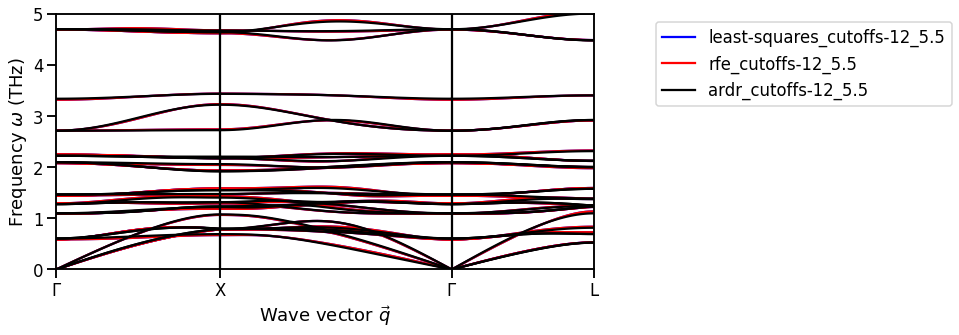

In [40]:
fig = plt.figure(figsize=(14, 5))
c=['b', 'r', 'k']# 'c']

Nq = 51

def get_band(q_start, q_stop, N):
    """ Return path between q_start and q_stop """
    return np.array([q_start + (q_stop-q_start)*i/(N-1) for i in range(N)])


# setup band path
G2X = get_band(np.array([0, 0, 0]), np.array([0.5, 0.5, 0]), Nq)
X2K2G = get_band(np.array([0.5, 0.5, 1.0]), np.array([0, 0, 0]), Nq)
G2L = get_band(np.array([0, 0, 0]), np.array([0.5, 0.5, 0.5]), Nq)
bands = [G2X, X2K2G, G2L]

atoms_phonopy = PhonopyAtoms(symbols=prim.get_chemical_symbols(),
                             scaled_positions=prim.get_scaled_positions(),
                             cell=prim.cell)
phonopy = Phonopy(atoms_phonopy, supercell_matrix=dim,
                  primitive_matrix=None)


supercell = phonopy.get_supercell()
supercell = Atoms(cell=supercell.cell, numbers=supercell.numbers, pbc=True,
                  scaled_positions=supercell.get_scaled_positions())


for i in range(0,3):
    fit_method=fit_methods[i]
    tag = '{}_cutoffs-{}'.format(fit_method, cutoffs_str)
    print(tag)
    fcp_fname = 'fcp_{}.fcp'.format(tag)
    fcp = ForceConstantPotential.read(fcp_fname)
    fcs = fcp.get_force_constants(supercell)   
 # get second order force constants
    fc2 = fcs.get_fc_array(order=2)
    phonopy.set_force_constants(fc2)
#print(fc2.shape)
# get phonon dispersion
    phonopy.set_band_structure(bands)
    qvecs, qnorms, freqs, _ = phonopy.get_band_structure()
    for q, freq, in zip(qnorms, freqs):
        plt.plot(q, freq, color=c[i])
        
    plt.plot(np.nan, np.nan, color=c[i], label=tag)    
    


kpts = [0.0, qnorms[0][-1], qnorms[1][-1], qnorms[2][-1]]
kpts_labels = ['$\\Gamma$', 'X', '$\\Gamma$', 'L']
plt.xlabel('Wave vector $\\vec{q}$')
plt.ylabel('Frequency $\\omega$ (THz)')
plt.axvline(x=kpts[1], color='k')
plt.axvline(x=kpts[2], color='k')
plt.xticks(kpts, kpts_labels)
plt.xlim([0.0, qnorms[-1][-1]])
plt.ylim([0.0, 5.0])
plt.legend(bbox_to_anchor=(1.1,1.0))
plt.tight_layout()